# Arbol elemental con libreria  rpart

## Introduccion

Este es el primer notebook/script de la materia Laboratorio de Implementacion I, se expone en la primera clase.
<br>Se utilizan Arboles de Decision, librería **rpart**,  el primer algoritmo, el más simple que utilizaremos en la materia pero que es el fundamento de los Ensembles de Arboles de Decision tales como  Random Forest y  Gradient Boosting of Decision Trees (XGBoost/LightGBM)
<br>La materia posee un dataset con 31 meses, en las primeras clases toda la cohorte, independiente de la modalidad elegida, utilizará **dataset_pequeno** que posee apenas un mes histórico 202107 y obviamente el mes donde se debe realizar la predicción 202109
<br>Este primer notebook/script **no** desarrolla todas las etapas necesarias para la generación de un buen modelo, apenas posee la parte final del pipeline/workflow.

### Limitaciones



Este primer y elemental notebook/script supone estas simplificaciónes:
* Solo se dispone del mes 202107 con el campo clase_ternaria completo, es el unico mes donde entrenar
* Se decidió previamente, de alguna forma, que la etapa de Final Training se hará sobre TODO el dataset de 202107
* Se obtuvieron previamente los hiperparámetros optimos de la libería **rpart** para este problema, mediante algun tipo de busqueda búsqueda.  Esta es la etapa que demandará decenas de horas para quienes opten por la *modalidad Analista Senior*
* No se realiza ningun tipo de feature engineering intra-mes
* Al no disponer de datos históricos no se realiza ningun tipo de feature engineering histórico
* No hay ningun analisis de la calidad de los campos, no se analiza si ocurrió alguna catástrofe ese mes y algun campo no se calculó correctamente
* Noy hay ningun tipo de análisis de Data Drifting entre los meses de 202107 y 202109
* Obedientemente se trabaja utlizando como clase el campo **clase_ternaria** sin ningun tipo de transformacion


<br> Obviamente, a lo largo de la materia se avanzará sobre todas las limitacinoes anteriores.

## Seteo del ambiente local

Esta parte se debe correr con un kernel de R local.
<br>En Jupyter, seleccionar el kernel **R** antes de ejecutar el notebook.

Los archivos persistentes quedan en el repo local: datasets en `datasets/` y resultados en `exp/`.

In [1]:
# Seteo local: correr este notebook desde la raiz del repo o desde src/arboles
if (basename(getwd()) == "arboles") {
  ROOT_DIR <- normalizePath(file.path(getwd(), "../.."), mustWork = TRUE)
} else {
  ROOT_DIR <- normalizePath(getwd(), mustWork = TRUE)
}

DATA_DIR <- file.path(ROOT_DIR, "datasets")
EXP_DIR <- file.path(ROOT_DIR, "exp")
KAGGLE_JSON <- file.path(ROOT_DIR, "kaggle.json")

Para correr localmente, el dataset debe estar en `datasets/` dentro del repo.

<br>Si se va a subir a Kaggle, copiar `kaggle.json` a la raiz del repo antes de correr la siguiente celda. La celda lo instala en `~/.kaggle/kaggle.json` con permisos correctos.



In [2]:
dir.create(DATA_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(EXP_DIR, recursive = TRUE, showWarnings = FALSE)

dataset_local <- file.path(DATA_DIR, "dataset_pequeno.csv")
if (!file.exists(dataset_local)) {
  stop("No encuentro el dataset en: ", dataset_local)
}

if (file.exists(KAGGLE_JSON)) {
  kaggle_dir <- path.expand("~/.kaggle")
  dir.create(kaggle_dir, recursive = TRUE, showWarnings = FALSE)
  file.copy(KAGGLE_JSON, file.path(kaggle_dir, "kaggle.json"), overwrite = TRUE)
  Sys.chmod(file.path(kaggle_dir, "kaggle.json"), mode = "0600")
} else {
  message("No encontre kaggle.json en la raiz del repo. Solo es necesario para hacer submit a Kaggle.")
}

## Final Train y generacion de la prediccion

Esta parte se debe correr con un kernel local de **R**.

limpio el ambiente de R

In [3]:
# # limpio la memoria
# rm(list=ls(all.names=TRUE)) # remove all objects
# gc(full=TRUE, verbose=FALSE) # garbage collection

* Instalacion de la libreria  rpart.plot  para dibujar el arbol
* invocacion de las librerias  **data.table**  **rpart** y  **rpart.plot**

In [4]:
# cargo las librerias que necesito
require("data.table")
require("rpart")
if (!require("rpart.plot")) install.packages("rpart.plot")
require("rpart.plot")

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: rpart

Loading required package: rpart.plot



Crear y moverse a la carpeta donde se va a trabajar

In [5]:
# carpeta de trabajo
experimento <- "KA2001"
dir.create(file.path(EXP_DIR, experimento), recursive = TRUE, showWarnings=FALSE)
setwd(file.path(EXP_DIR, experimento))

## Final Training

### Final Train Dataset

Es importante notar que para el entrenamiento final utilizo el mes de 202107 completo sin ningun tipo particion  train/test, aqui no hay random, aqui no hay semillas

In [6]:
# lectura del dataset
dataset <- fread(file.path(DATA_DIR, "dataset_pequeno.csv"))
dtrain_final <- dataset[foto_mes == 202107] # defino donde voy a entrenar

### Hyperparameters

Aqui los hiperparámetros estan hardcodeados
<br> Usted puede jugar con ellos manualmente
<br> En las siguientes clases veremos como encontrar previamente los hiperparámetros óptimos, para ser copiados aquí

In [7]:
param_final <- list (
  "cp"= -1, # complejidad minima
  "minsplit"= 250, # minima cantidad de regs en un nodo para hacer el split
  "minbucket"= 100, # minima cantidad de regs en una hoja
  "maxdepth"= 15# profundidad máxima del arbol
)

### Training

In [8]:
# genero el modelo,  aqui se construye el arbol
# quiero predecir clase_ternaria a partir de el resto de las variables
modelo_final <- rpart(
    formula= "clase_ternaria ~ .",
    data= dtrain_final, # los datos donde voy a entrenar
    xval= 0,
    control= param_final
)


#### Impresion del modelo

Warning message:
“labs do not fit even at cex 0.15, there may be some overplotting”


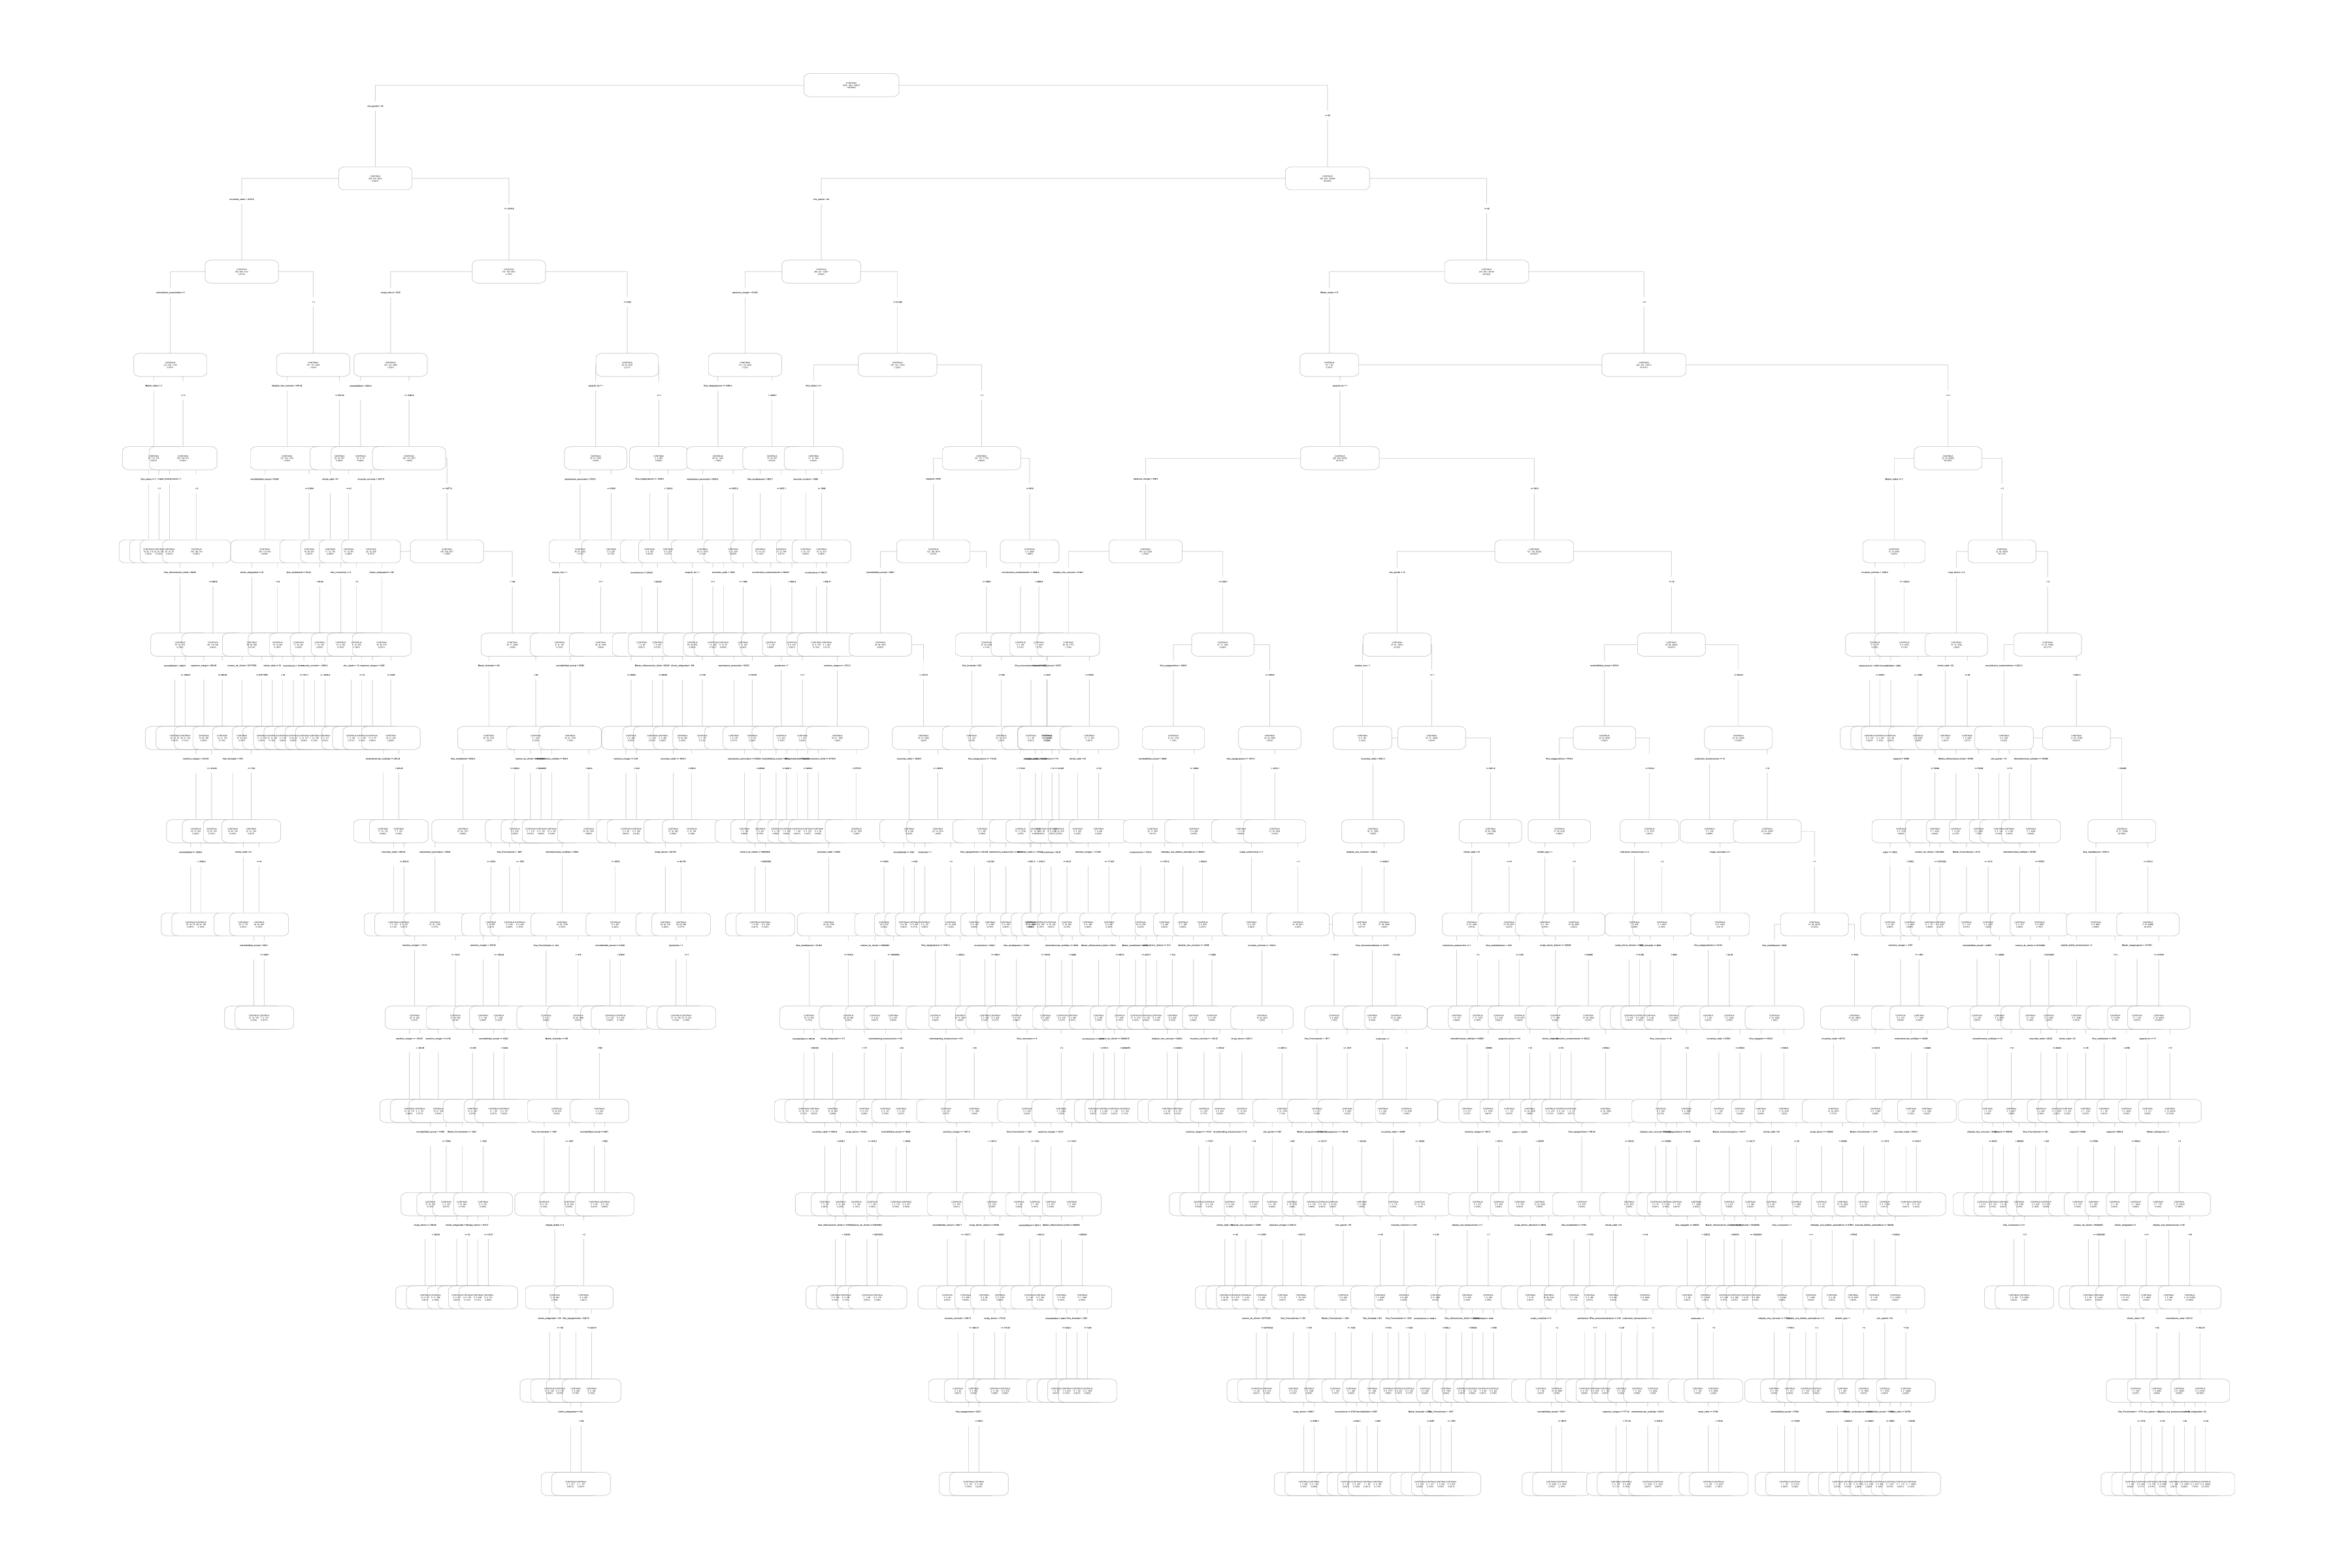

In [9]:
# grafico el arbol
options(repr.plot.width=30, repr.plot.height=20 )

prp(modelo_final,
    extra= 101,
    digits= -5,
    branch= 1,
    type= 4,
    varlen= 0,
    faclen= 0
)

## Dataset Future

Aqui se define el dataset donde quiero hacer la prediccion final, generalmente esto viene dado por el problema y es trivial su eleccion

In [13]:
dfuture <- dataset[foto_mes == 202109] # defino donde voy a aplicar el modelo

### Scoring

Aplico el modelo_final a los datos del futuro

In [14]:
# aplico el modelo a los datos nuevos
prediccion <- predict(
    object= modelo_final,
    newdata= dfuture,
    type= "prob"
)

# veo que  quedó en predccion
# es una matriz, una linea por registro del dataset dfuture
# una columna para cada uno de los valores de la clase
prediccion

,BAJA+1,BAJA+2,CONTINUA
1,0.000000e+00,4.441878e-05,0.9999556
2,0.000000e+00,0.000000e+00,1.0000000
3,0.000000e+00,0.000000e+00,1.0000000
4,0.000000e+00,4.441878e-05,0.9999556
5,0.000000e+00,1.762115e-03,0.9982379
6,1.388889e-02,2.777778e-02,0.9583333
7,1.000000e-02,0.000000e+00,0.9900000
8,1.980786e-04,9.903932e-05,0.9997029
9,0.000000e+00,0.000000e+00,1.0000000
10,0.000000e+00,4.441878e-05,0.9999556


## Tabla Prediccion

In [15]:
tb_prediccion <- as.data.table(list(
  "numero_de_cliente" = dfuture$numero_de_cliente,
  "prob"=prediccion[, "BAJA+2"]
))

## Decision

In [16]:
# decido a quien se envia estimulo y a quien no
# como trabajo con clase_ternaria puedo hacer el corte en 1/40
# solo le envio estimulo a los registros
#  con probabilidad de BAJA+2 mayor  a  1/40

tb_prediccion[, Predicted := prob > (1/40) ]

# veo que hay en tb_prediccion
tb_prediccion

numero_de_cliente,prob,Predicted
<int>,<dbl>,<lgl>
11673459,4.441878e-05,FALSE
11673463,0.000000e+00,FALSE
11674064,0.000000e+00,FALSE
11674166,4.441878e-05,FALSE
11674316,1.762115e-03,FALSE
11674337,2.777778e-02,TRUE
11674528,0.000000e+00,FALSE
11674689,9.903932e-05,FALSE
11674959,0.000000e+00,FALSE


## Kaggle

In [17]:
# genero el archivo para Kaggle
# en el formato requerido por Kaggle
# <numero_de_cliente, Predicted>  separados por coma, estension .csv

archivo_kaggle <- "K101_001.csv"

fwrite( tb_prediccion[, list(numero_de_cliente, Predicted)],
    file = archivo_kaggle,
    sep = ","
)

In [18]:
nrow( tb_prediccion )

[1] 165076

### Kaggle Competition Submit

Para hacer submit localmente, debe estar instalado el comando **kaggle** de Python. La celda de seteo local copia `kaggle.json` a `~/.kaggle/kaggle.json` si el archivo existe en la raiz del repo.

In [19]:
comando <- "kaggle competitions submit"
competencia <- "-c data-mining-inicial-2026-b"
arch <- paste( "-f", archivo_kaggle)

In [20]:
mensaje <-  paste0( "-m 'cp=", param_final$cp, "  minsplit=", param_final$minsplit, "  minbucket=", param_final$minbucket, "  maxdepth=", param_final$maxdepth, "'")

In [21]:
linea <- paste( comando, competencia, arch, mensaje)

# este el el comando que correria desde el prompt de Linux
linea

[1] "kaggle competitions submit -c data-mining-inicial-2026-b -f K101_001.csv -m 'cp=-1  minsplit=250  minbucket=100  maxdepth=15'"

In [22]:
# ejecuto el comando
salida <- system(linea, intern=TRUE)
cat(salida)

99 submissions remaining today. Successfully submitted to Data Mining, Inicial 2026 B

## Tarea para el Hogar

Explorar manualmente que hiperparámetros genera una mayor ganancia en Kaggle
<br> Si en un momento logra quedar en primera posición del Private Leaderboard, saquese una selfie